In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

#### Combine into one big DataFrame

In [7]:
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']

dfs = []
for country in countries:
    path = f'../data/{country}_clean.csv'
    df = pd.read_csv(path)
    df['COUNTRY'] = country.capitalize()
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print("Total rows:", len(df_all))


Total rows: 20540


### Temperature Trend Comparision

In [15]:
print("Extracting month and year for grouping")
df_all['DATE'] = pd.to_datetime(df_all['DATE'])
df_all['MONTH'] = df_all['DATE'].dt.month
df_all['YEAR'] = df_all['DATE'].dt.year

print("Calculating average monthly temperatures")
monthly_temp = df_all.groupby(['COUNTRY', 'MONTH'])['T2M'].mean().reset_index()
print("Monthly averages calculated:" , len(monthly_temp))

Extracting month and year for grouping
Calculating average monthly temperatures
Monthly averages calculated: 60


In [24]:
df_all

,COUNTRY,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
0,Ethiopia,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,2015-01-01,1
1,Ethiopia,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,2015-01-02,1
2,Ethiopia,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,2015-01-03,1
3,Ethiopia,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,2015-01-04,1
4,Ethiopia,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20535,Tanzania,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,2026-03-27,3
20536,Tanzania,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,2026-03-28,3
20537,Tanzania,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,2026-03-29,3
20538,Tanzania,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,2026-03-30,3


#### Plotting Temperature Average

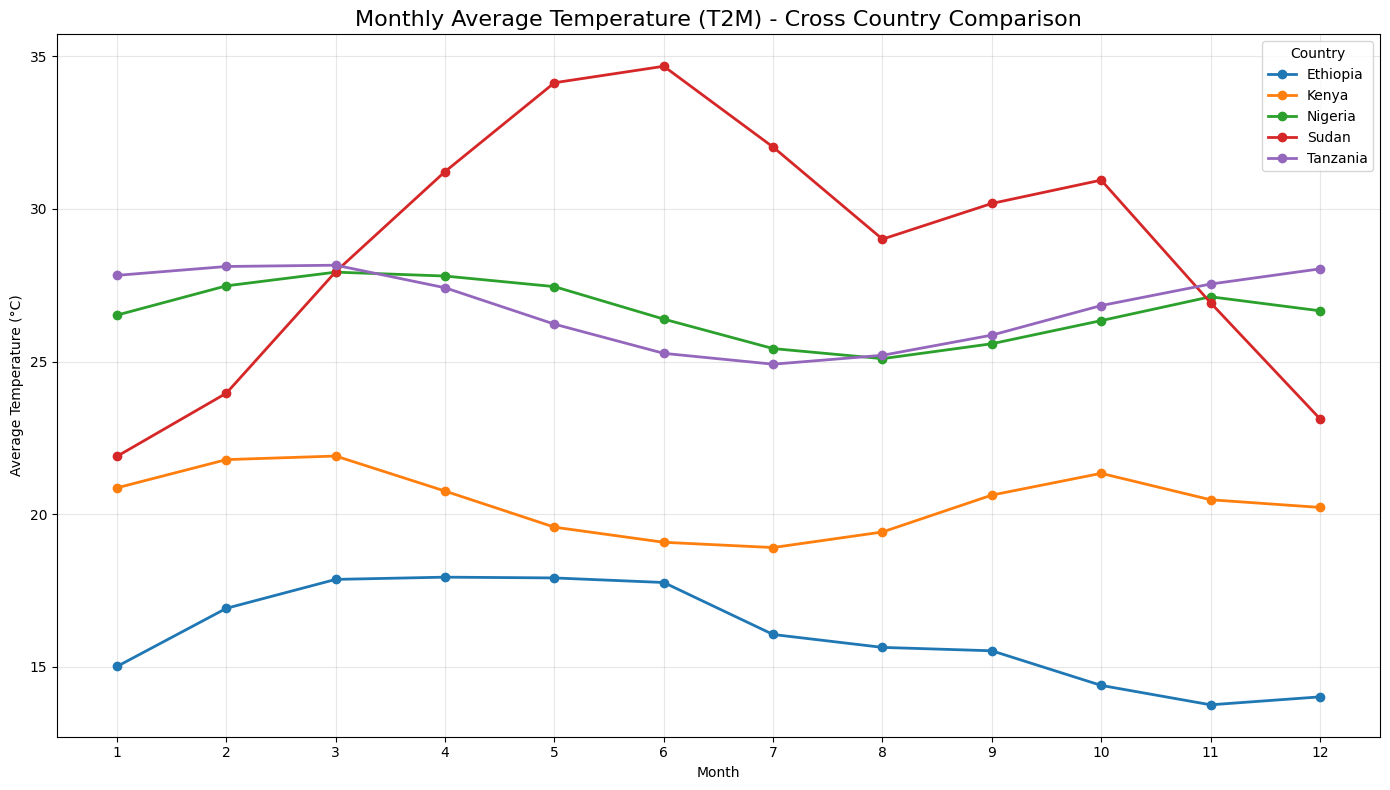

In [16]:

plt.figure(figsize=(14, 8))
for country in monthly_temp['COUNTRY'].unique():
    country_data = monthly_temp[monthly_temp['COUNTRY'] == country]
    plt.plot(country_data['MONTH'], country_data.groupby('MONTH')['T2M'].mean(), 
             marker='o', linewidth=2, label=country)

plt.title('Monthly Average Temperature (T2M) - Cross Country Comparison', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(range(1, 13))
plt.legend(title='Country')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Temperature Summary Table

In [18]:
temp_summary = df_all.groupby('COUNTRY')['T2M'].agg(['mean', 'median', 'std']).round(2)
temp_summary = temp_summary.rename(columns={
    'mean': 'Mean T2M (°C)',
    'median': 'Median T2M (°C)',
    'std': 'Std Dev T2M (°C)'
})

print("Temperature Summary Across Countries:")
display(temp_summary)

Temperature Summary Across Countries:


,Mean T2M (°C),Median T2M (°C),Std Dev T2M (°C)
COUNTRY,,,
Ethiopia,16.07,16.04,1.90
Kenya,20.43,20.36,1.44
Nigeria,26.66,26.82,1.12
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33


### Precipitation Variability (Boxplots + Summary)

Precipitation Summary Across Countries:


,Mean Rainfall (mm/day),Median Rainfall (mm/day),Std Dev Rainfall (mm/day)
COUNTRY,,,
Ethiopia,3.634,0.82,6.289
Kenya,1.468,0.38,3.180
Nigeria,4.214,1.84,7.267
Sudan,0.644,0.00,3.058
Tanzania,3.740,0.64,8.004


Boxplot for Precipitation:


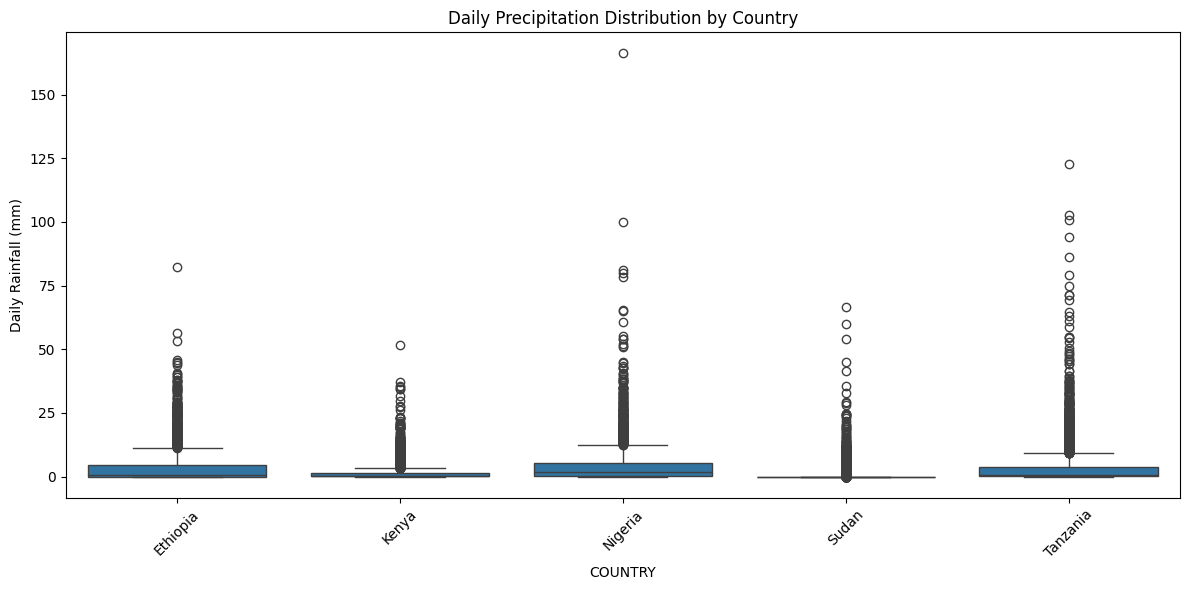

In [20]:
precip_summary = df_all.groupby('COUNTRY')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(3)
precip_summary = precip_summary.rename(columns={
    'mean': 'Mean Rainfall (mm/day)',
    'median': 'Median Rainfall (mm/day)',
    'std': 'Std Dev Rainfall (mm/day)'
})

print("Precipitation Summary Across Countries:")
display(precip_summary)

print("Boxplot for Precipitation:")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_all, x='COUNTRY', y='PRECTOTCORR')
plt.title('Daily Precipitation Distribution by Country')
plt.ylabel('Daily Rainfall (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Extreme Events Frequency

#### Extreme Heat Events

Count extreme heat days per year per country:
Average Extreme Heat Days per Year (>35°C):


,COUNTRY,Avg Extreme Heat Days per Year
0,Sudan,224.5


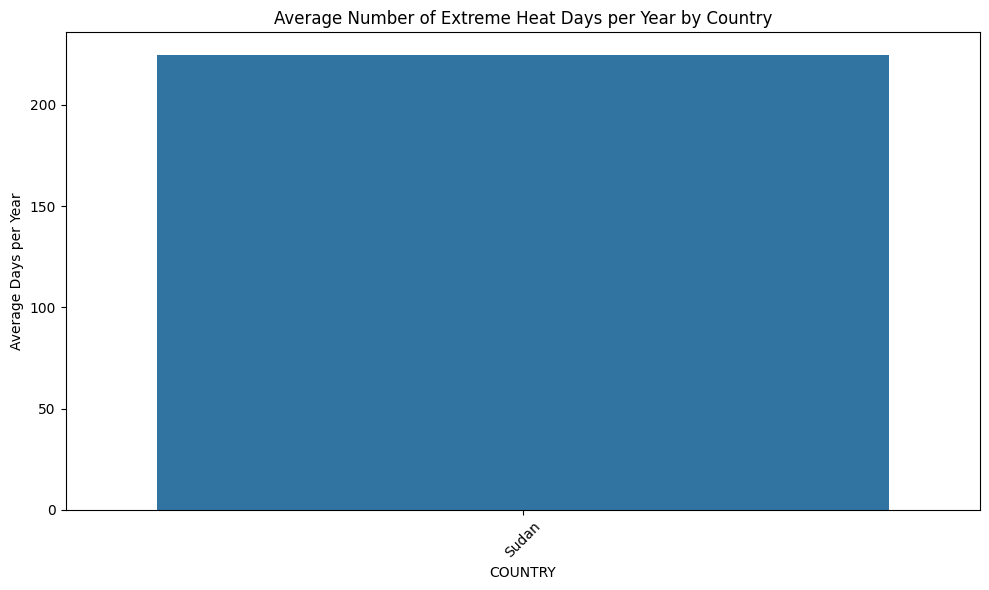

In [22]:
print("Count extreme heat days per year per country:")
extreme_heat = df_all[df_all['T2M_MAX'] > 35].groupby(['COUNTRY', 'YEAR']).size().reset_index(name='Extreme_Heat_Days')

# Average extreme heat days per year
heat_summary = extreme_heat.groupby('COUNTRY')['Extreme_Heat_Days'].mean().round(1).reset_index()
heat_summary = heat_summary.rename(columns={'Extreme_Heat_Days': 'Avg Extreme Heat Days per Year'})

print("Average Extreme Heat Days per Year (>35°C):")
display(heat_summary)

# Bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=heat_summary, x='COUNTRY', y='Avg Extreme Heat Days per Year')
plt.title('Average Number of Extreme Heat Days per Year by Country')
plt.ylabel('Average Days per Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Consecutive Dry Days Analysis

In [25]:

def max_consecutive_dry_days(group):
    dry = (group['PRECTOTCORR'] < 1).astype(int)
    dry['group'] = (dry != dry.shift()).cumsum()
    return dry.groupby('group').sum().max()

dry_days_per_year = []

for country in df_all['COUNTRY'].unique():
    country_data = df_all[df_all['COUNTRY'] == country].copy()
    yearly_dry = country_data.groupby('YEAR').apply(max_consecutive_dry_days).reset_index(name='Max_Consecutive_Dry_Days')
    yearly_dry['COUNTRY'] = country
    dry_days_per_year.append(yearly_dry)

dry_summary = pd.concat(dry_days_per_year, ignore_index=True)
dry_avg = dry_summary.groupby('COUNTRY')['Max_Consecutive_Dry_Days'].mean().round(1).reset_index()
dry_avg = dry_avg.rename(columns={'Max_Consecutive_Dry_Days': 'Avg Max Consecutive Dry Days per Year'})

print("Average Maximum Consecutive Dry Days per Year:")
display(dry_avg)

# Bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=dry_avg, x='COUNTRY', y='Avg Max Consecutive Dry Days per Year')
plt.title('Average Maximum Consecutive Dry Days per Year by Country')
plt.ylabel('Average Days')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'group'

### Statistical Test (Kruskal-Wallis)

In [28]:

groups = [df_all[df_all['COUNTRY'] == country]['T2M'] for country in df_all['COUNTRY'].unique()]

stat, p_value = stats.kruskal(*groups)

print("Kruskal-Wallis Test on Temperature (T2M) across 5 countries:")
print(f"Statistic: {stat:.2f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("→ There is a statistically significant difference in temperatures between countries.")
else:
    print("→ No statistically significant difference in temperatures between countries.")

Kruskal-Wallis Test on Temperature (T2M) across 5 countries:
Statistic: 15392.99
p-value: 0.0000
→ There is a statistically significant difference in temperatures between countries.


### Vulnerability Ranking Table

In [ ]:
ranking = pd.DataFrame({
    'Country': ['Nigeria', 'Sudan', 'Kenya', 'Tanzania', 'Ethiopia'],
    'Avg_Temperature': [df_all[df_all['COUNTRY'] == c]['T2M'].mean() for c in ['Nigeria', 'Sudan', 'Kenya', 'Tanzania', 'Ethiopia']],
    'Extreme_Heat_Days': heat_summary.set_index('COUNTRY').loc[['Nigeria','Sudan','Kenya','Tanzania','Ethiopia'], 'Avg Extreme Heat Days per Year'],
    'Consecutive_Dry_Days': dry_avg.set_index('COUNTRY').loc[['Nigeria','Sudan','Kenya','Tanzania','Ethiopia'], 'Avg Max Consecutive Dry Days per Year'],
    'Rainfall_Variability': precip_summary.loc[['Nigeria','Sudan','Kenya','Tanzania','Ethiopia'], 'Std Dev Rainfall (mm/day)']
}).round(2)

# Simple composite vulnerability score (higher = more vulnerable)
ranking['Vulnerability_Score'] = (
    ranking['Extreme_Heat_Days'] * 0.4 +
    ranking['Consecutive_Dry_Days'] * 0.35 +
    ranking['Rainfall_Variability'] * 0.25
).round(2)

ranking = ranking.sort_values('Vulnerability_Score', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1

print("Climate Vulnerability Ranking:")
display(ranking)

KeyError: "['Nigeria', 'Kenya', 'Tanzania', 'Ethiopia'] not in index"

In [29]:
df_all.head()

,COUNTRY,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
0,Ethiopia,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1
1,Ethiopia,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1
2,Ethiopia,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1
3,Ethiopia,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1
4,Ethiopia,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1


In [32]:
countries = df_all['COUNTRY'].unique()
print("Countries in dataset:", countries)

Countries in dataset: ['Ethiopia' 'Kenya' 'Nigeria' 'Sudan' 'Tanzania']
